### Question 1. 

#### Fragment length frequency

You are given a file (see link below) with each line indicating where a DNA fragment has mapped
on the chromosome. Your goal is to count individual fragment lengths, and then
normalize it by the total count of all fragment lengths. Once you have the
normalized count, you will plot that using plotting packages in Python. X-axis
will be fragment length (unit: base pairs) and Y-axis will be labelled
"Narmalized Frequency [A.U.]". Fragment length can simply be calculated by
subtracting 2nd column from the 3rd.

[query.bed.gz](https://figshare.com/ndownloader/files/53306780?private_link=727f8d920a1b8415f09a) 

#### Rescaling

Often, you will received two sets of data with differnt emperical distribution.
The goal is to rescale one (query) to the other (reference). In this part, you
will write codes to achieve this. You are given a reference distribution
(`reference.hist`) and a query bed file (query.bed.gz). You have to rescale
(subsample the data) so that when you draw the normalized frequency, it should
almost match the reference. 

[reference.hist](https://figshare.com/ndownloader/files/53306810?private_link=727f8d920a1b8415f09a)

-------


In [1]:
# importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import gzip

In [2]:
# reading query.bed.gz
col_names = ['chrom', 'start', 'end', 'score', 'strand_1', 'strand_2']
with gzip.open('query.bed.gz', 'rt') as f:
    df = pd.read_csv(f, sep='\t', names=col_names, header=None)

#reading reference.hist
reference_df = pd.read_csv('reference.hist', sep='\t', header=None, names=['fragment_length', 'frequency'])

df.head()
reference_df.head()

# fragment_length
df['fragment_length'] = df['end'] - df['start']

#counting occurrences of each fragment_length
length_counts = df['fragment_length'].value_counts().sort_index()

#normalizing the counts
normalized_counts = length_counts / length_counts.sum()

/var/folders/8m/yxpgk6ls5298k30x04bn8j240000gn/T/ipykernel_16278/2033081895.py:4: DtypeWarning: Columns (3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f, sep='\t', names=col_names, header=None)


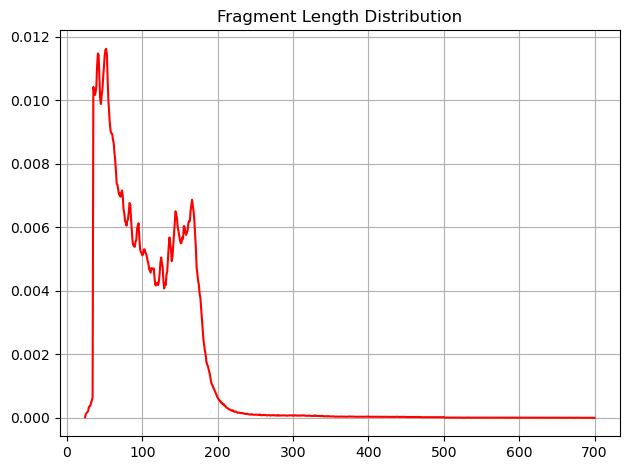

In [3]:
#plotting
plt.plot(normalized_counts.index, normalized_counts.values, color='red')
plt.title("Fragment Length Distribution")
plt.grid(True)
plt.tight_layout()
plt.show()

---------------


### What have we done so far?
We have written a code to read the bed file and calculate the fragment length
frequency and normalized counts. 
We have also written a code to plot the normalized frequency.
We have also written a code to read the reference histogram.

----------------------------------------------------------------------

In [4]:
total_fragments = len(df)
desired_counts = (reference_df['frequency'] * total_fragments).astype(int)
desired_counts = pd.Series(desired_counts.values, index=reference_df['fragment_length'])

# sampling the query data
fragment_groups = df.groupby('fragment_length')
selected_fragments = []

for frag_len, count in desired_counts.items():
    if frag_len in fragment_groups.groups:
        group = fragment_groups.get_group(frag_len)
        sampled = group.sample(n=count, random_state=42) if len(group) >= count else group
        selected_fragments.append(sampled)

rescaled_df = pd.concat(selected_fragments, ignore_index=True)


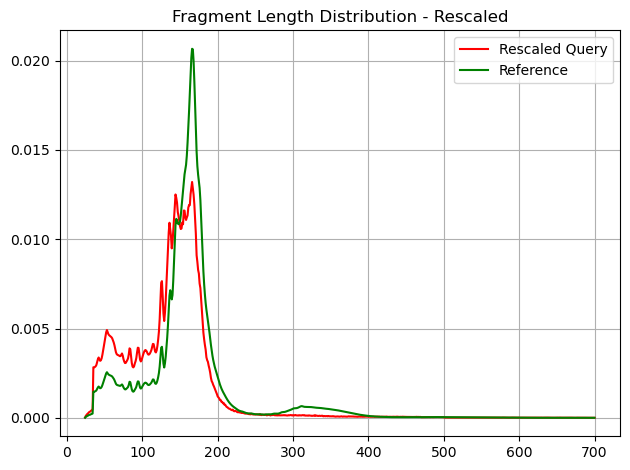

In [5]:
rescaled_length_counts = rescaled_df['fragment_length'].value_counts().sort_index()
rescaled_normalized_counts = rescaled_length_counts / rescaled_length_counts.sum()

plt.plot(rescaled_normalized_counts.index, rescaled_normalized_counts.values, color='red', label='Rescaled Query')
plt.plot(reference_df['fragment_length'], reference_df['frequency'], color='green', label='Reference')

plt.title("Fragment Length Distribution - Rescaled")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Summary
In this notebook, we worked with a bed file containing DNA fragment mapping data.
We calculated the fragment length frequency and normalized counts, and plotted
the normalized frequency. We also read a reference histogram and wrote a code
to rescale the query data to match the reference distribution.
We also wrote a code to rescale the query data to match the reference
distribution.
We used the `matplotlib` libraries for plotting.
We also used the `pandas` library for data manipulation and analysis.
